<a href="https://colab.research.google.com/github/aditya5203/Artificial-Intelligence-and-Machine-Learning/blob/main/Artificial_Intelligence_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning-Based Brain Tumor Classification Using MRI Scans

## Task 2: Computer Vision Task

This notebook implements an end-to-end image classification project using MRI brain scan images. The task includes:

1. Dataset understanding and visualization
2. Image preprocessing and augmentation
3. Baseline CNN from scratch
4. Deeper CNN with regularization
5. Optimizer comparison: Adam vs SGD
6. Ablation study
7. Transfer learning using EfficientNetB3
8. Model evaluation using accuracy, precision, recall, F1-score, confusion matrix, and AUC-ROC
9. Sample predictions
10. Grad-CAM visualization
11. Final model comparison

In [ ]:
# =========================
# 1. INSTALL AND IMPORT LIBRARIES
# =========================

!pip install -q opencv-python

import os
import random
import shutil
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# =========================
# 2. MOUNT GOOGLE DRIVE
# =========================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =========================
# 3. SET RANDOM SEED
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [ ]:
# =========================
# 4. DATASET PATH SETUP
# =========================

# Your folder spelling may be "Classifcation" or "Classification".
# This code checks both possible paths.

possible_dataset_paths = [
    "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/Brain Tumor Classifcation",
    "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/Brain Tumor Classification",
    "/content/drive/MyDrive/Brain Tumor Classifcation",
    "/content/drive/MyDrive/Brain Tumor Classification"
]

DATASET_DIR = None

for path in possible_dataset_paths:
    if os.path.exists(path):
        DATASET_DIR = path
        break

if DATASET_DIR is None:
    raise FileNotFoundError(
        "Dataset folder not found. Please check your Google Drive dataset path."
    )

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Dataset directory:", DATASET_DIR)
print("Train directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError("Train folder not found inside dataset directory.")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError("Test folder not found inside dataset directory.")

Dataset directory: /content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/Brain Tumor Classifcation
Train directory exists: True
Test directory exists: True


In [ ]:
# =========================
# 5. CHECK CLASS NAMES
# =========================

class_names = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(i, class_name)

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

Detected classes:
0 glioma_tumor
1 meningioma_tumor
2 normal
3 pituitary_tumor
Number of classes: 4


In [ ]:
# =========================
# 6. REMOVE CORRUPTED IMAGES
# =========================

def remove_corrupted_images(directory):
    corrupted_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

            except Exception:
                corrupted_files.append(file_path)

    for file_path in corrupted_files:
        try:
            os.remove(file_path)
        except Exception as e:
            print("Could not remove:", file_path, e)

    return corrupted_files


train_corrupted = remove_corrupted_images(TRAIN_DIR)
test_corrupted = remove_corrupted_images(TEST_DIR)

print("Corrupted training images removed:", len(train_corrupted))
print("Corrupted testing images removed:", len(test_corrupted))

Corrupted training images removed: 0
Corrupted testing images removed: 0


In [ ]:
# =========================
# 6. REMOVE CORRUPTED IMAGES
# =========================

def remove_corrupted_images(directory):
    corrupted_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

            except Exception:
                corrupted_files.append(file_path)

    for file_path in corrupted_files:
        try:
            os.remove(file_path)
        except Exception as e:
            print("Could not remove:", file_path, e)

    return corrupted_files


train_corrupted = remove_corrupted_images(TRAIN_DIR)
test_corrupted = remove_corrupted_images(TEST_DIR)

print("Corrupted training images removed:", len(train_corrupted))
print("Corrupted testing images removed:", len(test_corrupted))

Corrupted training images removed: 0
Corrupted testing images removed: 0


In [ ]:
# =========================
# 7. DATASET IMAGE COUNT
# =========================

def count_images(directory):
    data = []

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            image_files = [
                file for file in os.listdir(class_path)
                if file.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            data.append({
                "Class": class_name,
                "Image Count": len(image_files)
            })

    return pd.DataFrame(data)


train_count_df = count_images(TRAIN_DIR)
test_count_df = count_images(TEST_DIR)

print("Training image distribution:")
display(train_count_df)

print("Testing image distribution:")
display(test_count_df)

total_train = train_count_df["Image Count"].sum()
total_test = test_count_df["Image Count"].sum()

print("Total training images:", total_train)
print("Total testing images:", total_test)
print("Total images:", total_train + total_test)

Training image distribution:


,Class,Image Count
0,glioma_tumor,713
1,meningioma_tumor,723
2,normal,343
3,pituitary_tumor,668


Testing image distribution:


,Class,Image Count
0,glioma_tumor,181
1,meningioma_tumor,183
2,normal,88
3,pituitary_tumor,169


Total training images: 2447
Total testing images: 621
Total images: 3068


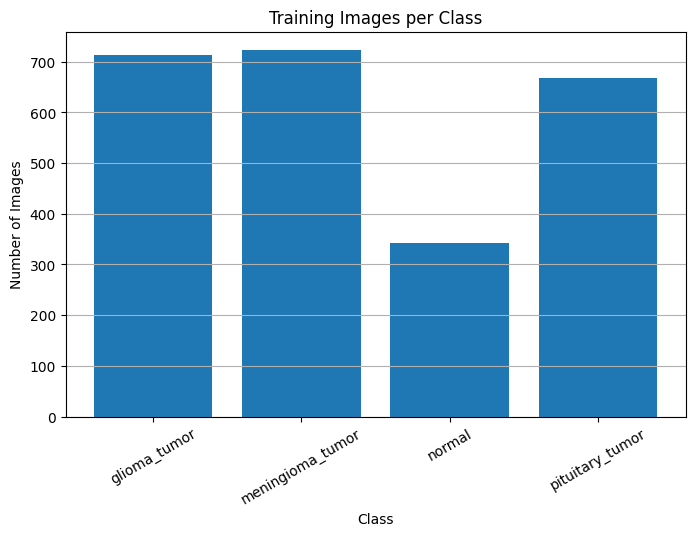

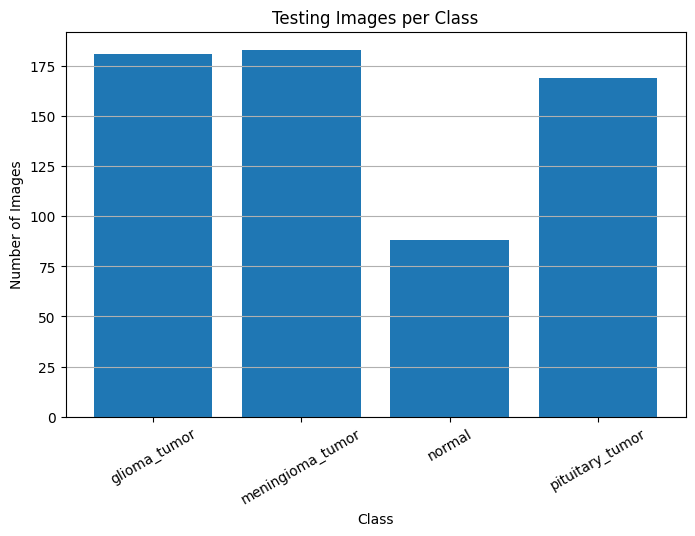

In [ ]:
# =========================
# 8. VISUALIZE CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(8, 5))
plt.bar(train_count_df["Class"], train_count_df["Image Count"])
plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(test_count_df["Class"], test_count_df["Image Count"])
plt.title("Testing Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

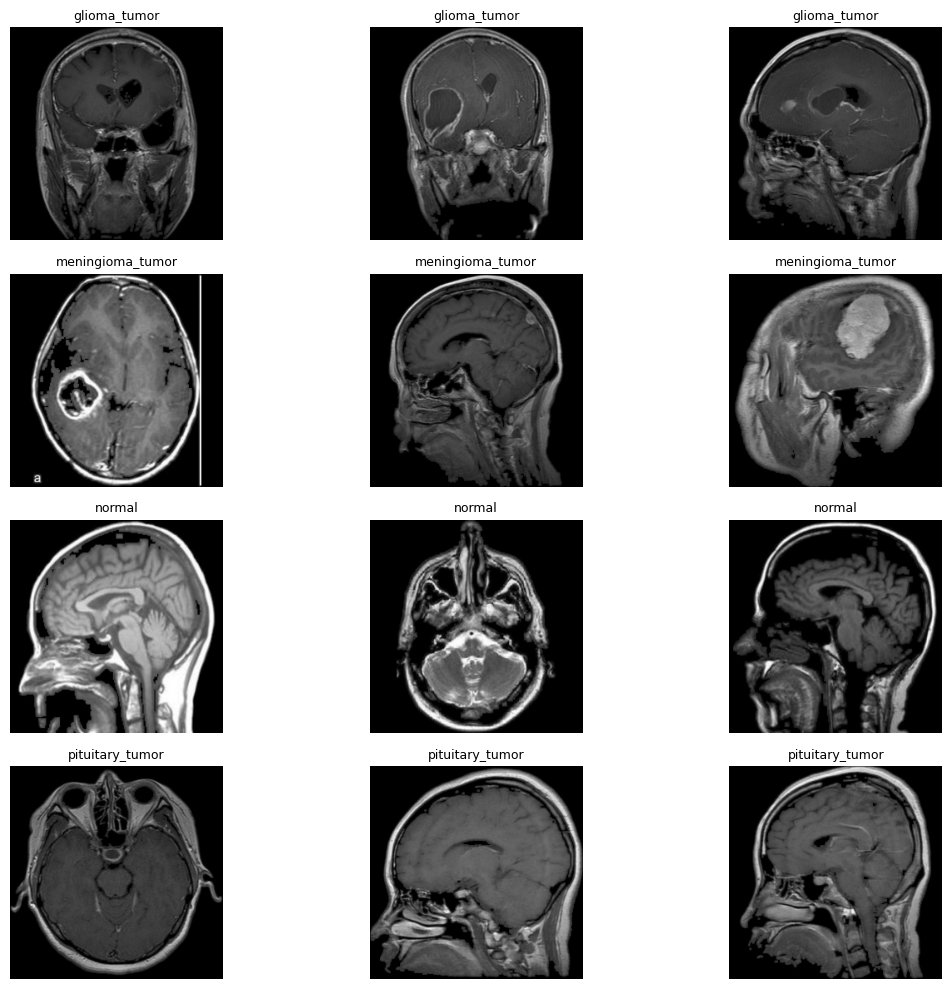

In [ ]:
# =========================
# 9. DISPLAY SAMPLE MRI IMAGES
# =========================

def show_sample_images(directory, class_names, samples_per_class=3):
    plt.figure(figsize=(12, 10))

    image_index = 1

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)

        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        selected_images = random.sample(
            image_files,
            min(samples_per_class, len(image_files))
        )

        for image_file in selected_images:
            image_path = os.path.join(class_path, image_file)
            img = Image.open(image_path).convert("RGB")

            plt.subplot(len(class_names), samples_per_class, image_index)
            plt.imshow(img)
            plt.axis("off")
            plt.title(class_name, fontsize=9)

            image_index += 1

    plt.tight_layout()
    plt.show()


show_sample_images(TRAIN_DIR, class_names, samples_per_class=3)

In [ ]:
# =========================
# 10. CREATE TRAIN AND VALIDATION SPLIT
# =========================

image_paths = []
labels = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, file))
            labels.append(class_name)

data_df = pd.DataFrame({
    "filename": image_paths,
    "class": labels
})

train_df, val_df = train_test_split(
    data_df,
    test_size=0.15,
    stratify=data_df["class"],
    random_state=SEED
)

print("Training samples after split:", len(train_df))
print("Validation samples:", len(val_df))

print("Training class distribution:")
display(train_df["class"].value_counts())

print("Validation class distribution:")
display(val_df["class"].value_counts())

Training samples after split: 2079
Validation samples: 368
Training class distribution:


,count
class,
meningioma_tumor,614
glioma_tumor,606
pituitary_tumor,568
normal,291


Validation class distribution:


,count
class,
meningioma_tumor,109
glioma_tumor,107
pituitary_tumor,100
normal,52


In [ ]:
# =========================
# 11. CREATE TEST DATAFRAME
# =========================

test_image_paths = []
test_labels = []

for class_name in class_names:
    class_path = os.path.join(TEST_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(class_path, file))
            test_labels.append(class_name)

test_df = pd.DataFrame({
    "filename": test_image_paths,
    "class": test_labels
})

print("Testing samples:", len(test_df))
display(test_df["class"].value_counts())

Testing samples: 621


,count
class,
meningioma_tumor,183
glioma_tumor,181
pituitary_tumor,169
normal,88


In [ ]:
# =========================
# 12. DATA GENERATORS FOR CNN MODELS
# =========================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

print("Class indices:", class_indices)
print("Class names:", class_names)

Found 2079 validated image filenames belonging to 4 classes.
Found 368 validated image filenames belonging to 4 classes.
Found 621 validated image filenames belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}
Class names: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [ ]:
# =========================
# 13. COMPUTE CLASS WEIGHTS
# =========================

y_train_labels = train_df["class"].values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for index, weight in class_weights.items():
    print(class_names[index], ":", weight)

Class weights:
glioma_tumor : 0.8576732673267327
meningioma_tumor : 0.8464983713355049
normal : 1.7860824742268042
pituitary_tumor : 0.9150528169014085


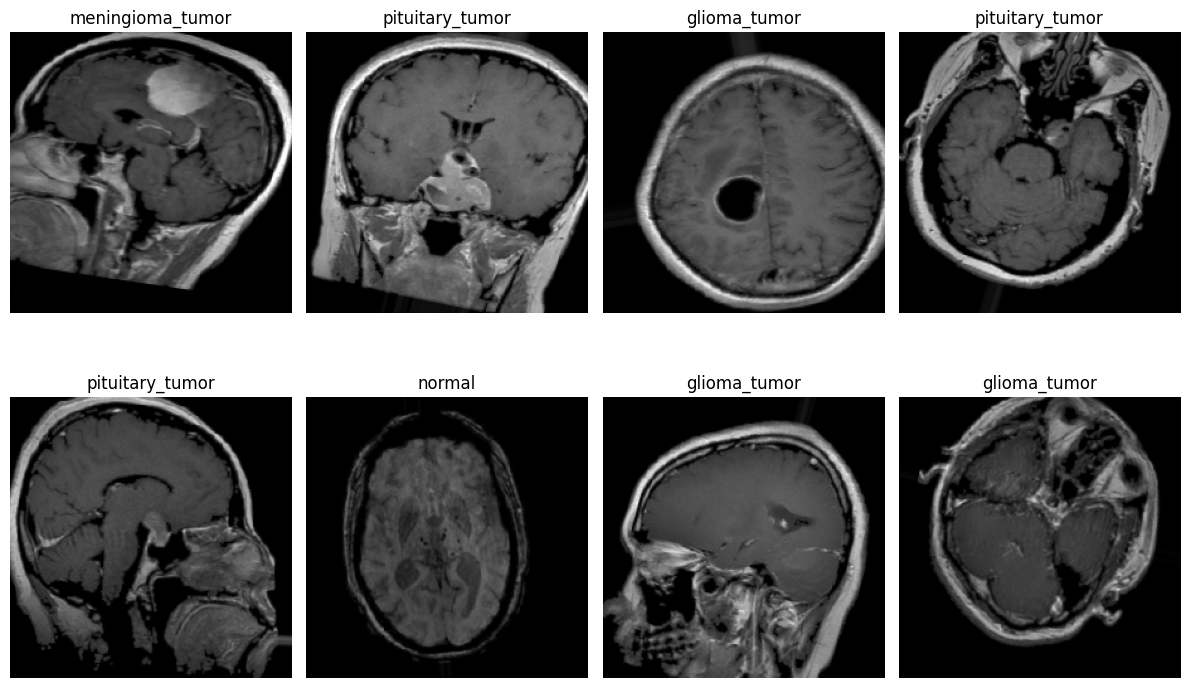

In [ ]:
# =========================
# 14. VISUALIZE AUGMENTED IMAGES
# =========================

sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])
    plt.axis("off")
    label_index = np.argmax(sample_labels[i])
    plt.title(class_names[label_index])

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 15. CALLBACKS
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

In [ ]:
# =========================
# 16. HELPER FUNCTION FOR EVALUATION
# =========================

def evaluate_model(model, generator, model_name):
    generator.reset()

    loss, acc = model.evaluate(generator, verbose=1)

    pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(pred_probs, axis=1)
    y_true = generator.classes

    print(f"\n{model_name} Test Loss:", loss)
    print(f"{model_name} Test Accuracy:", acc)

    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(xticks_rotation=30)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return loss, acc, pred_probs, y_true, y_pred

In [ ]:
# =========================
# 17. HELPER FUNCTION FOR TRAINING CURVES
# =========================

def plot_training_curves(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# 18. MODEL 1 - BASELINE CNN FROM SCRATCH
# Requirement: 3 Conv + Pooling layers, 3 fully connected layers, output layer
# =========================

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,084 (85.01 MB)

 Trainable params: 22,286,084 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# 19. TRAIN BASELINE CNN
# =========================

start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

baseline_time = time.time() - start_time

print("Baseline CNN Training Time:", baseline_time)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 56s 690ms/step - accuracy: 0.2569 - loss: 1.3689 - val_accuracy: 0.4484 - val_loss: 1.2837 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 617ms/step - accuracy: 0.3151 - loss: 1.3133 - val_accuracy: 0.4511 - val_loss: 1.2012 - learning_rate: 1.0000e-04
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 566ms/step - accuracy: 0.4454 - loss: 1.1864 - val_accuracy: 0.6087 - val_loss: 0.9960 - learning_rate: 1.0000e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 590ms/step - accuracy: 0.4998 - loss: 1.0859 - val_accuracy: 0.6060 - val_loss: 0.9509 - learning_rate: 1.0000e-04
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 583ms/step - accuracy: 0.5652 - loss: 1.0082 - val_accuracy: 0.5788 - val_loss: 0.9993 - learning_rate: 1.0000e-04
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 599ms/step - accuracy: 0.5637 - loss: 0.9704 - val_accuracy: 0.5000 - val_loss: 1.1296 - learning_rate: 1.0000e-04
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accu

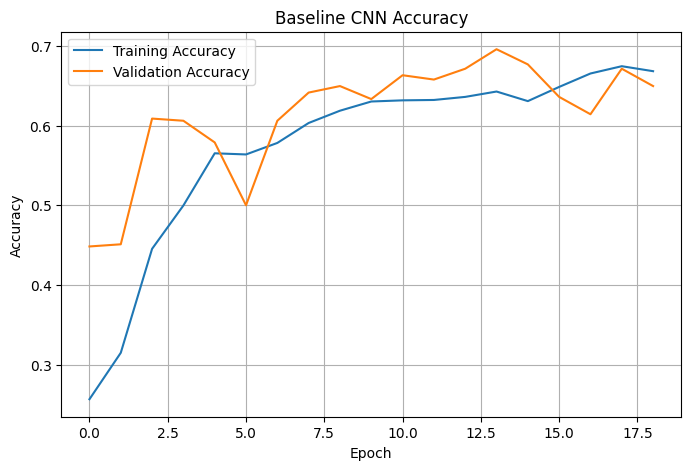

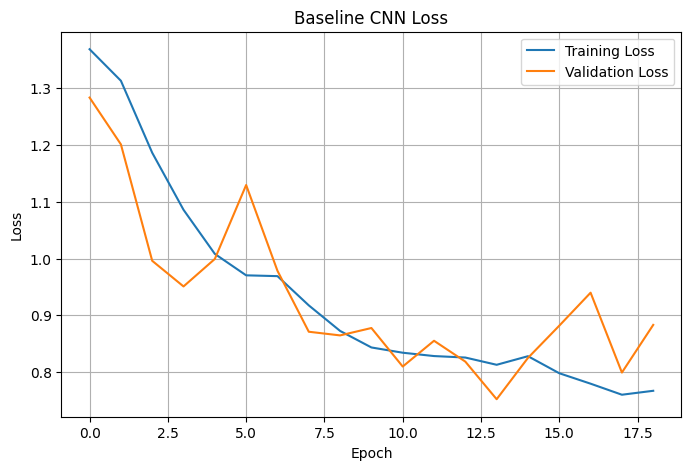

In [ ]:
# =========================
# 20. BASELINE CNN TRAINING CURVES
# =========================

plot_training_curves(history_baseline, "Baseline CNN")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.6844 - loss: 0.8062
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step

Baseline CNN Test Loss: 0.8062134981155396
Baseline CNN Test Accuracy: 0.684380054473877

Baseline CNN Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.71      0.73      0.72       181
meningioma_tumor       0.70      0.34      0.46       183
          normal       0.59      0.80      0.68        88
 pituitary_tumor       0.71      0.95      0.81       169

        accuracy                           0.68       621
       macro avg       0.68      0.70      0.67       621
    weighted avg       0.69      0.68      0.66       621



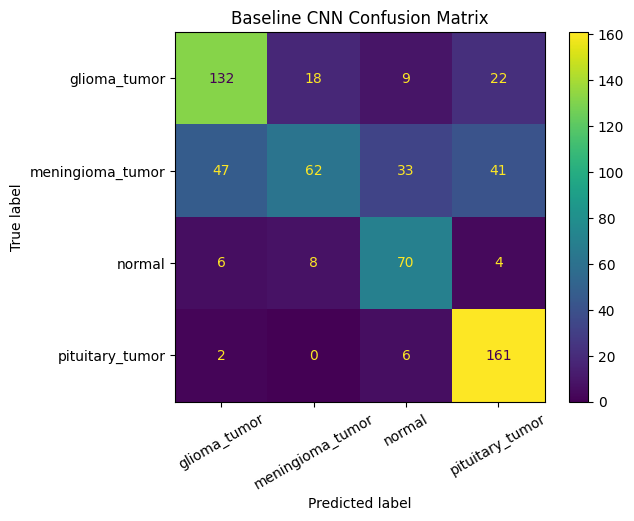

In [ ]:
# =========================
# 21. BASELINE CNN EVALUATION
# =========================

baseline_loss, baseline_acc, baseline_pred_probs, y_true, baseline_pred = evaluate_model(
    baseline_model,
    test_generator,
    "Baseline CNN"
)

In [ ]:
# =========================
# 22. MODEL 2 - DEEPER CNN WITH REGULARIZATION
# This model uses 6 Conv2D layers, double the baseline CNN.
# =========================

def build_deep_cnn_model(optimizer_name="adam", use_dropout=True):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(224, 224, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25) if use_dropout else tf.keras.layers.Activation("linear"),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.30) if use_dropout else tf.keras.layers.Activation("linear"),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.40) if use_dropout else tf.keras.layers.Activation("linear"),

        Flatten(),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.50) if use_dropout else tf.keras.layers.Activation("linear"),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.40) if use_dropout else tf.keras.layers.Activation("linear"),

        Dense(64, activation="relu"),
        Dropout(0.30) if use_dropout else tf.keras.layers.Activation("linear"),

        Dense(NUM_CLASSES, activation="softmax")
    ])

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=0.0001)

    elif optimizer_name == "sgd":
        optimizer = SGD(learning_rate=0.01, momentum=0.9)

    else:
        optimizer = optimizer_name

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# =========================
# 23. BUILD DEEP CNN WITH ADAM
# =========================

deep_model = build_deep_cnn_model(
    optimizer_name="adam",
    use_dropout=True
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,022,116 (99.27 MB)

 Trainable params: 26,020,452 (99.26 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# =========================
# 24. TRAIN DEEP CNN WITH ADAM
# =========================

start_time = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

deep_time = time.time() - start_time

print("Deep CNN Adam Training Time:", deep_time)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.3069 - loss: 1.9459 - val_accuracy: 0.2853 - val_loss: 1.7087 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 612ms/step - accuracy: 0.3617 - loss: 1.6323 - val_accuracy: 0.1413 - val_loss: 2.5526 - learning_rate: 1.0000e-04
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.4014 - loss: 1.5353
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 631ms/step - accuracy: 0.4045 - loss: 1.5024 - val_accuracy: 0.1413 - val_loss: 3.3724 - learning_rate: 1.0000e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 624ms/step - accuracy: 0.4204 - loss: 1.4506 - val_accuracy: 0.1413 - val_loss: 3.4393 - learning_rate: 3.0000e-05
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 598ms/step - accuracy: 0.4180 - loss: 1.4537 - val_accuracy: 0.1359 - val_loss: 3.5630 - learning_rate: 3.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of t

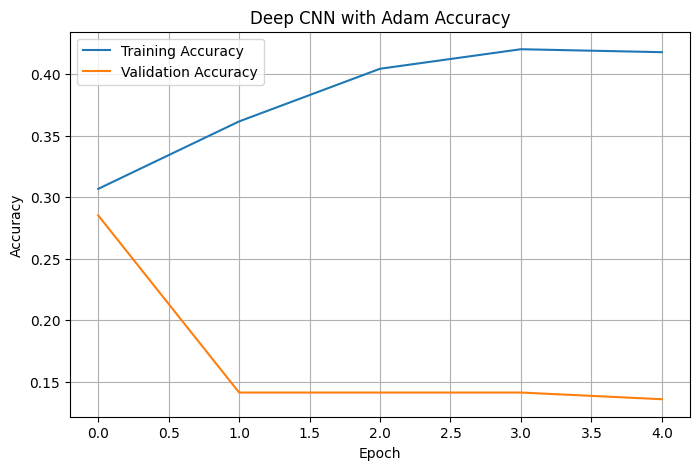

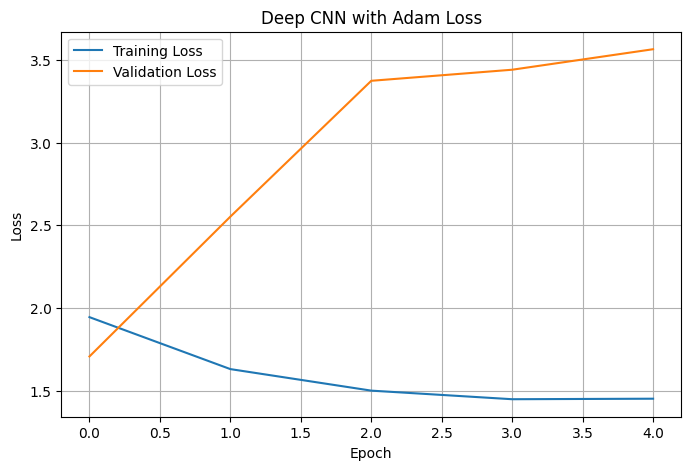

In [ ]:
# =========================
# 25. DEEP CNN ADAM TRAINING CURVES
# =========================

plot_training_curves(history_deep, "Deep CNN with Adam")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.2770 - loss: 1.7089
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step

Deep CNN Adam Test Loss: 1.7088526487350464
Deep CNN Adam Test Accuracy: 0.27697262167930603

Deep CNN Adam Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.00      0.00      0.00       183
          normal       0.30      0.03      0.06        88
 pituitary_tumor       0.28      1.00      0.43       169

        accuracy                           0.28       621
       macro avg       0.14      0.26      0.12       621
    weighted avg       0.12      0.28      0.13       621



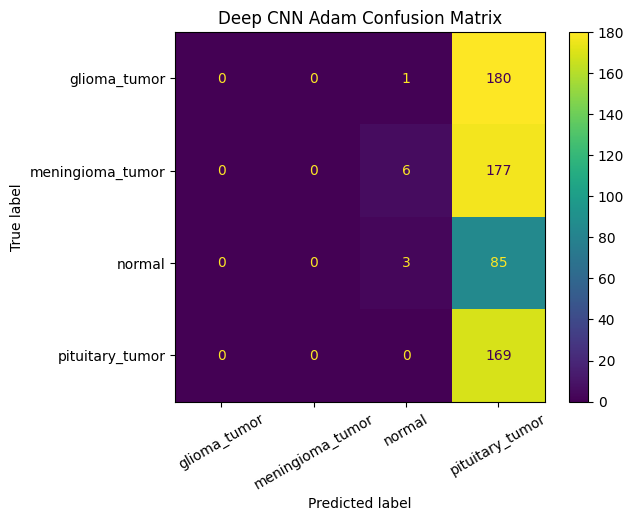

In [ ]:
# =========================
# 26. DEEP CNN ADAM EVALUATION
# =========================

deep_loss, deep_acc, deep_pred_probs, y_true, deep_pred = evaluate_model(
    deep_model,
    test_generator,
    "Deep CNN Adam"
)

In [ ]:
# =========================
# 27. OPTIMIZER COMPARISON - DEEP CNN WITH SGD
# =========================

deep_sgd_model = build_deep_cnn_model(
    optimizer_name="sgd",
    use_dropout=True
)

deep_sgd_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,022,116 (99.27 MB)

 Trainable params: 26,020,452 (99.26 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# =========================
# 28. TRAIN DEEP CNN WITH SGD
# =========================

start_time = time.time()

history_deep_sgd = deep_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

deep_sgd_time = time.time() - start_time

print("Deep CNN SGD Training Time:", deep_sgd_time)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 61s 763ms/step - accuracy: 0.3482 - loss: 1.5459 - val_accuracy: 0.1413 - val_loss: 12.8415 - learning_rate: 0.0100
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 64s 598ms/step - accuracy: 0.4233 - loss: 1.2582 - val_accuracy: 0.3288 - val_loss: 1.5855 - learning_rate: 0.0100
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.4383 - loss: 1.2593
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0029999999329447745.
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 623ms/step - accuracy: 0.4444 - loss: 1.2105 - val_accuracy: 0.3533 - val_loss: 1.4034 - learning_rate: 0.0100
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 623ms/step - accuracy: 0.4887 - loss: 1.1360 - val_accuracy: 0.4402 - val_loss: 1.4831 - learning_rate: 0.0030
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 626ms/step - accuracy: 0.5200 - loss: 1.0980 - val_accuracy: 0.4103 - val_loss: 1.3014 - learning_rate: 0.0030
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


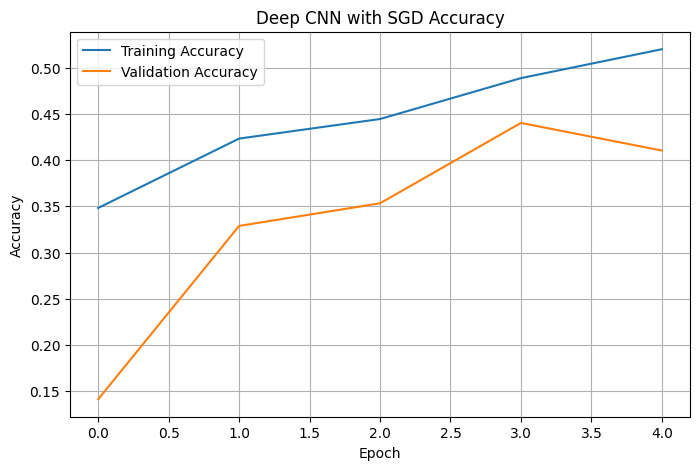

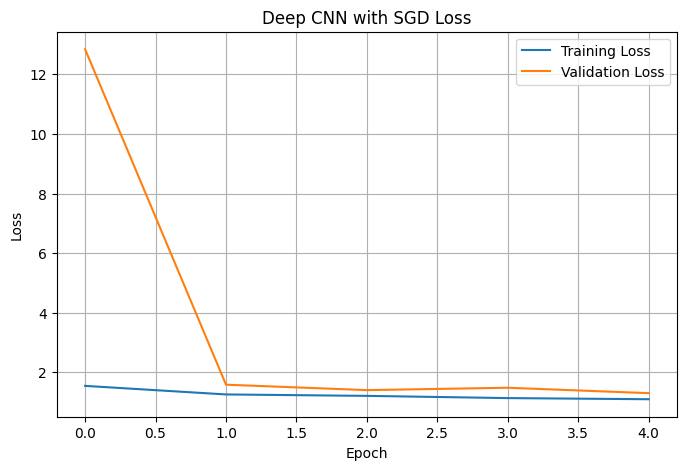

In [ ]:
# =========================
# 29. DEEP CNN SGD TRAINING CURVES
# =========================

plot_training_curves(history_deep_sgd, "Deep CNN with SGD")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.1417 - loss: 13.1880
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step

Deep CNN SGD Test Loss: 13.188030242919922
Deep CNN SGD Test Accuracy: 0.1417069286108017

Deep CNN SGD Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.00      0.00      0.00       183
          normal       0.14      1.00      0.25        88
 pituitary_tumor       0.00      0.00      0.00       169

        accuracy                           0.14       621
       macro avg       0.04      0.25      0.06       621
    weighted avg       0.02      0.14      0.04       621



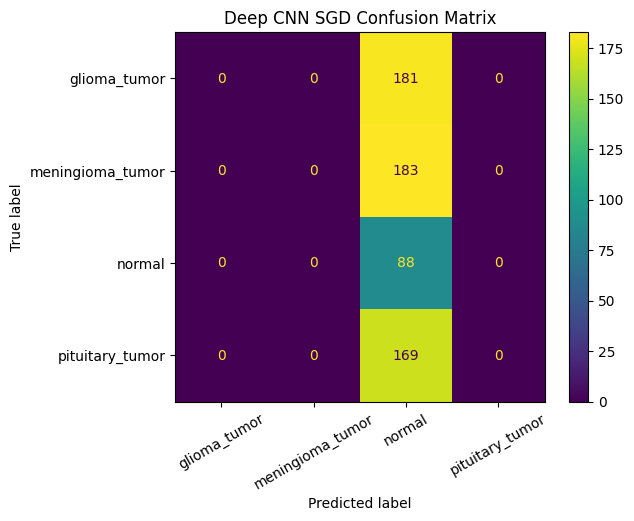

In [ ]:
# =========================
# 30. DEEP CNN SGD EVALUATION
# =========================

sgd_loss, sgd_acc, sgd_pred_probs, y_true, sgd_pred = evaluate_model(
    deep_sgd_model,
    test_generator,
    "Deep CNN SGD"
)

In [ ]:
# =========================
# 31. ABLATION STUDY - REMOVE DROPOUT
# =========================

ablation_model = build_deep_cnn_model(
    optimizer_name="adam",
    use_dropout=False
)

ablation_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,022,116 (99.27 MB)

 Trainable params: 26,020,452 (99.26 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# =========================
# 32. TRAIN ABLATION MODEL
# =========================

start_time = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

ablation_time = time.time() - start_time

print("Ablation Model Training Time:", ablation_time)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 56s 713ms/step - accuracy: 0.5017 - loss: 1.1754 - val_accuracy: 0.1413 - val_loss: 1.7559 - learning_rate: 1.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 601ms/step - accuracy: 0.6061 - loss: 0.8879 - val_accuracy: 0.1413 - val_loss: 1.7544 - learning_rate: 1.0000e-04
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.6695 - loss: 0.7689
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 612ms/step - accuracy: 0.6729 - loss: 0.7415 - val_accuracy: 0.2745 - val_loss: 2.0770 - learning_rate: 1.0000e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 620ms/step - accuracy: 0.7345 - loss: 0.6380 - val_accuracy: 0.2962 - val_loss: 2.1597 - learning_rate: 3.0000e-05
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 622ms/step - accuracy: 0.7412 - loss: 0.5919 - val_accuracy: 0.3533 - val_loss: 2.0088 - learning_rate: 3.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of

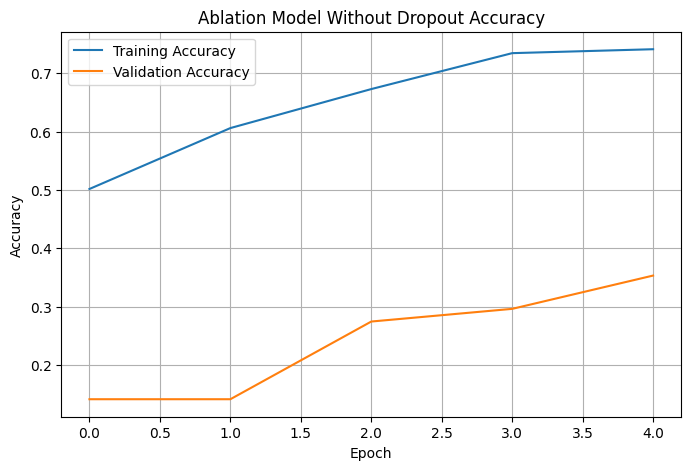

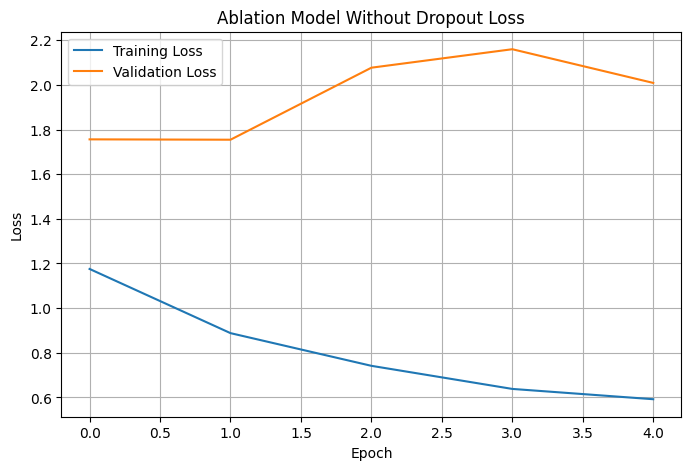

In [ ]:
# =========================
# 33. ABLATION MODEL TRAINING CURVES
# =========================

plot_training_curves(history_ablation, "Ablation Model Without Dropout")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.1417 - loss: 1.7587
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step

Ablation No Dropout Test Loss: 1.7587108612060547
Ablation No Dropout Test Accuracy: 0.1417069286108017

Ablation No Dropout Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       181
meningioma_tumor       0.00      0.00      0.00       183
          normal       0.14      1.00      0.25        88
 pituitary_tumor       0.00      0.00      0.00       169

        accuracy                           0.14       621
       macro avg       0.04      0.25      0.06       621
    weighted avg       0.02      0.14      0.04       621



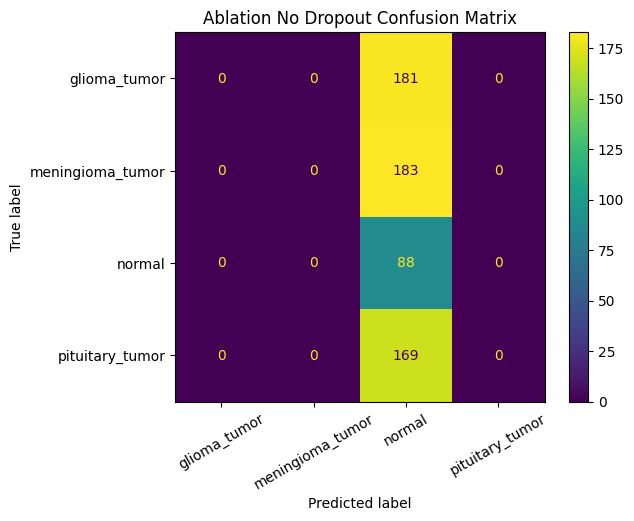

In [ ]:
# =========================
# 34. ABLATION MODEL EVALUATION
# =========================

ablation_loss, ablation_acc, ablation_pred_probs, y_true, ablation_pred = evaluate_model(
    ablation_model,
    test_generator,
    "Ablation No Dropout"
)

In [ ]:
# =========================
# 35. DATA GENERATORS FOR EFFICIENTNETB3
# EfficientNetB3 uses ImageNet preprocessing.
# =========================

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

tl_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

tl_train_generator = tl_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

tl_val_generator = tl_val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

tl_test_generator = tl_val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2079 validated image filenames belonging to 4 classes.
Found 368 validated image filenames belonging to 4 classes.
Found 621 validated image filenames belonging to 4 classes.


In [ ]:
# =========================
# 36. MODEL 3 - EFFICIENTNETB3 TRANSFER LEARNING
# =========================

efficientnet_base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_base.trainable = False

inputs = Input(shape=(224, 224, 3))

x = efficientnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

efficientnet_model = Model(inputs, outputs)

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
# =========================
# 37. PHASE 1 - FEATURE EXTRACTION
# Base model frozen
# =========================

start_time = time.time()

history_eff_phase1 = efficientnet_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

eff_phase1_time = time.time() - start_time

print("EfficientNetB3 Phase 1 Training Time:", eff_phase1_time)

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6570 - loss: 0.9538 - val_accuracy: 0.7636 - val_loss: 0.6122 - learning_rate: 0.0010
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 600ms/step - accuracy: 0.7672 - loss: 0.6410 - val_accuracy: 0.8071 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 577ms/step - accuracy: 0.8191 - loss: 0.4601 - val_accuracy: 0.8342 - val_loss: 0.4388 - learning_rate: 0.0010
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 599ms/step - accuracy: 0.8167 - loss: 0.4688 - val_accuracy: 0.8234 - val_loss: 0.4751 - learning_rate: 0.0010
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 605ms/step - accuracy: 0.8292 - loss: 0.4258 - val_accuracy: 0.8505 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 584ms/step - accuracy: 0.8543 - loss: 0.3549 - val_accuracy: 0.8451 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 7/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 582ms/step - accuracy: 0.8595 - loss: 0.35

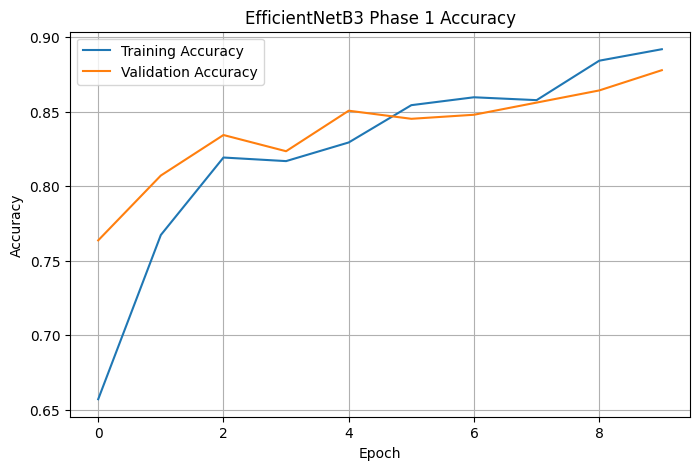

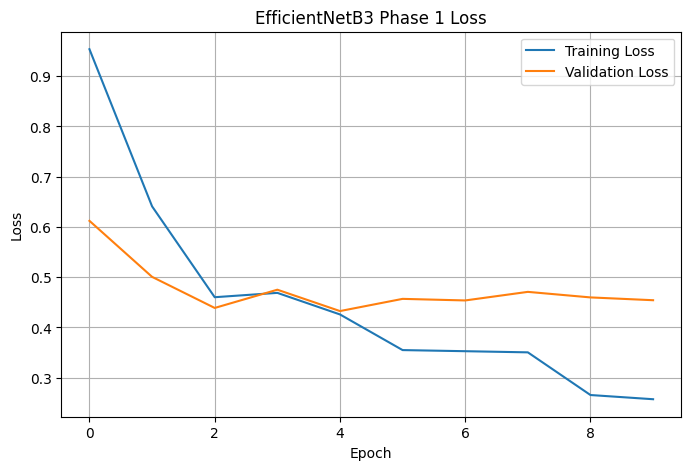

In [ ]:
# =========================
# 38. EFFICIENTNETB3 PHASE 1 TRAINING CURVES
# =========================

plot_training_curves(history_eff_phase1, "EfficientNetB3 Phase 1")

In [ ]:
# =========================
# 39. PHASE 2 - FINE-TUNING TOP 40% OF BASE MODEL
# =========================

efficientnet_base.trainable = True

total_layers = len(efficientnet_base.layers)
fine_tune_from = int(total_layers * 0.60)

print("Total EfficientNetB3 layers:", total_layers)
print("Fine-tuning from layer index:", fine_tune_from)

for layer in efficientnet_base.layers[:fine_tune_from]:
    layer.trainable = False

for layer in efficientnet_base.layers[fine_tune_from:]:
    layer.trainable = True

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

Total EfficientNetB3 layers: 385
Fine-tuning from layer index: 231


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 9,619,350 (36.69 MB)

 Non-trainable params: 1,564,829 (5.97 MB)

In [ ]:
# =========================
# 40. TRAIN EFFICIENTNETB3 PHASE 2
# =========================

start_time = time.time()

history_eff_phase2 = efficientnet_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

eff_phase2_time = time.time() - start_time

print("EfficientNetB3 Phase 2 Training Time:", eff_phase2_time)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.6936 - loss: 0.7908 - val_accuracy: 0.8207 - val_loss: 0.5366 - learning_rate: 1.0000e-05
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 606ms/step - accuracy: 0.7460 - loss: 0.6201 - val_accuracy: 0.7962 - val_loss: 0.6239 - learning_rate: 1.0000e-05
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7846 - loss: 0.5255
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 605ms/step - accuracy: 0.7816 - loss: 0.5501 - val_accuracy: 0.7935 - val_loss: 0.6312 - learning_rate: 1.0000e-05
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 624ms/step - accuracy: 0.7912 - loss: 0.5214 - val_accuracy: 0.8071 - val_loss: 0.6151 - learning_rate: 3.0000e-06
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 637ms/step - accuracy: 0.7888 - loss: 0.5401 - val_accuracy: 0.7962 - val_loss: 0.6029 - learning_rate: 3.0000e-06
Epoch 5: early stopping
Restoring model weights from the end of t

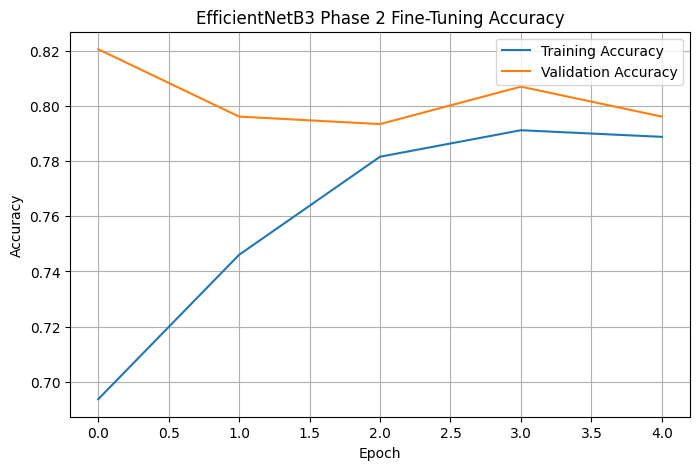

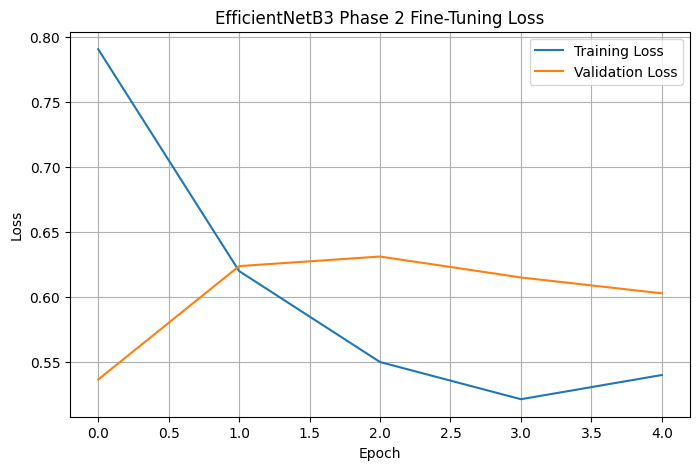

In [ ]:
# =========================
# 41. EFFICIENTNETB3 PHASE 2 TRAINING CURVES
# =========================

plot_training_curves(history_eff_phase2, "EfficientNetB3 Phase 2 Fine-Tuning")

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8245 - loss: 0.5385
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 686ms/step

EfficientNetB3 Transfer Learning Test Loss: 0.5384900569915771
EfficientNetB3 Transfer Learning Test Accuracy: 0.8244766592979431

EfficientNetB3 Transfer Learning Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.89      0.82      0.85       181
meningioma_tumor       0.83      0.68      0.75       183
          normal       0.88      0.89      0.88        88
 pituitary_tumor       0.75      0.95      0.84       169

        accuracy                           0.82       621
       macro avg       0.84      0.83      0.83       621
    weighted avg       0.83      0.82      0.82       621



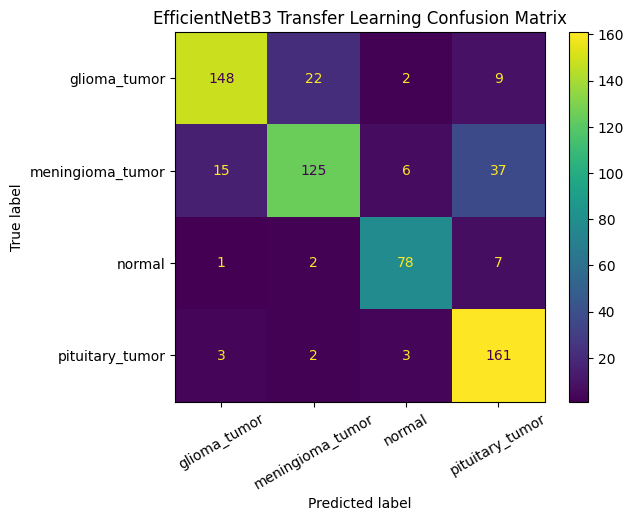

In [ ]:
# =========================
# 42. EFFICIENTNETB3 FINAL EVALUATION
# =========================

eff_loss, eff_acc, eff_pred_probs, y_true_tl, eff_pred = evaluate_model(
    efficientnet_model,
    tl_test_generator,
    "EfficientNetB3 Transfer Learning"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


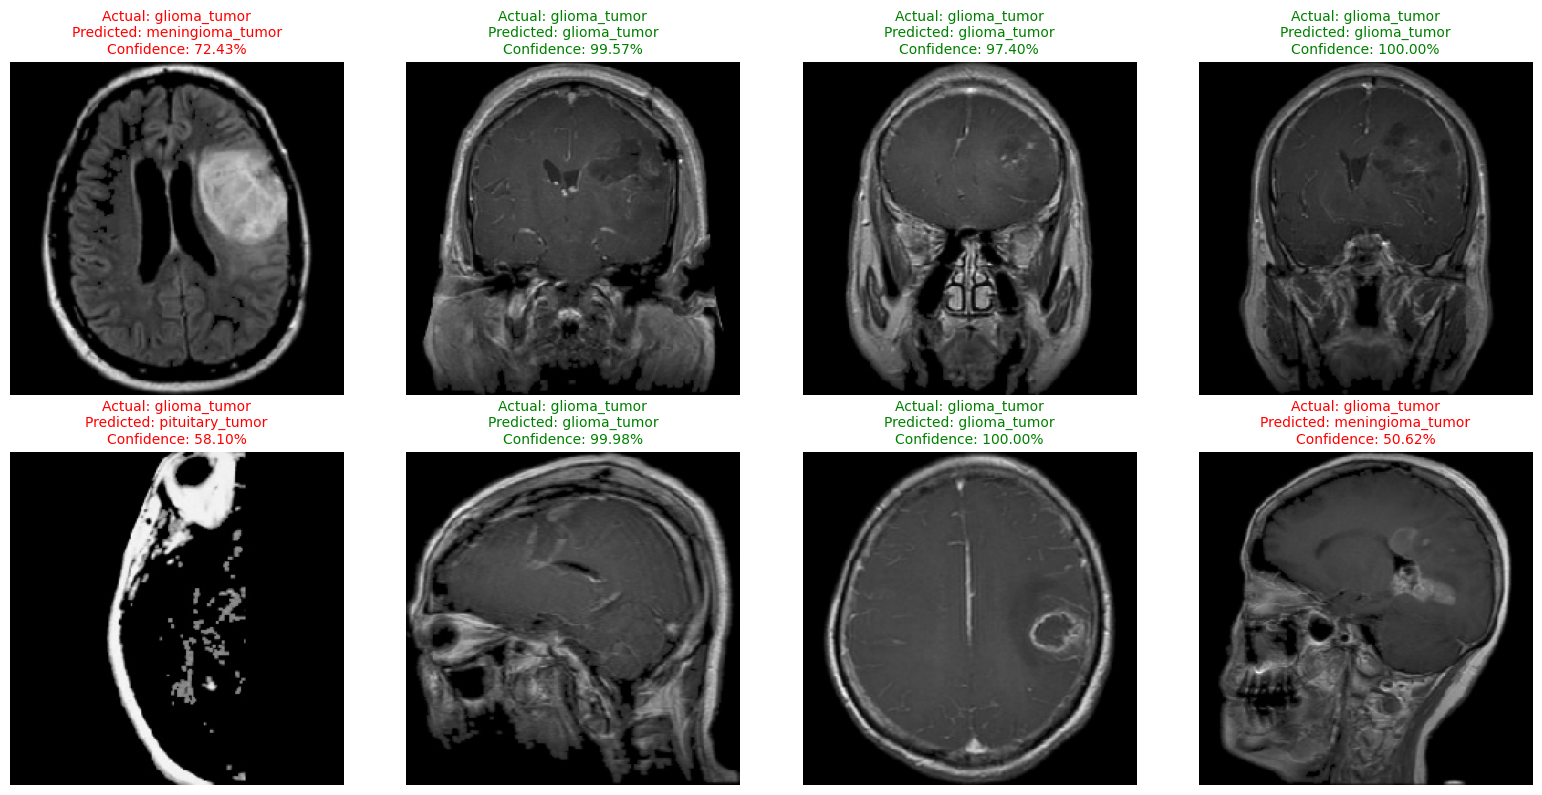

In [ ]:
# =========================
# 43. SAMPLE IMAGE PREDICTIONS
# =========================

def display_image_safely(img):
    img = np.array(img)

    if img.max() > 1:
        img = img / 255.0

    img = np.clip(img, 0, 1)

    return img


def show_sample_predictions(model, generator, class_names, num_images=8):
    generator.reset()

    images, labels = next(generator)
    predictions = model.predict(images)

    y_true_sample = np.argmax(labels, axis=1)
    y_pred_sample = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    plt.figure(figsize=(16, 8))

    total_images = min(num_images, len(images))

    for i in range(total_images):
        plt.subplot(2, 4, i + 1)

        img = display_image_safely(images[i])
        plt.imshow(img)
        plt.axis("off")

        actual = class_names[y_true_sample[i]]
        predicted = class_names[y_pred_sample[i]]
        conf = confidence[i] * 100

        title_color = "green" if actual == predicted else "red"

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}\nConfidence: {conf:.2f}%",
            color=title_color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


show_sample_predictions(
    model=efficientnet_model,
    generator=tl_test_generator,
    class_names=class_names,
    num_images=8
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step


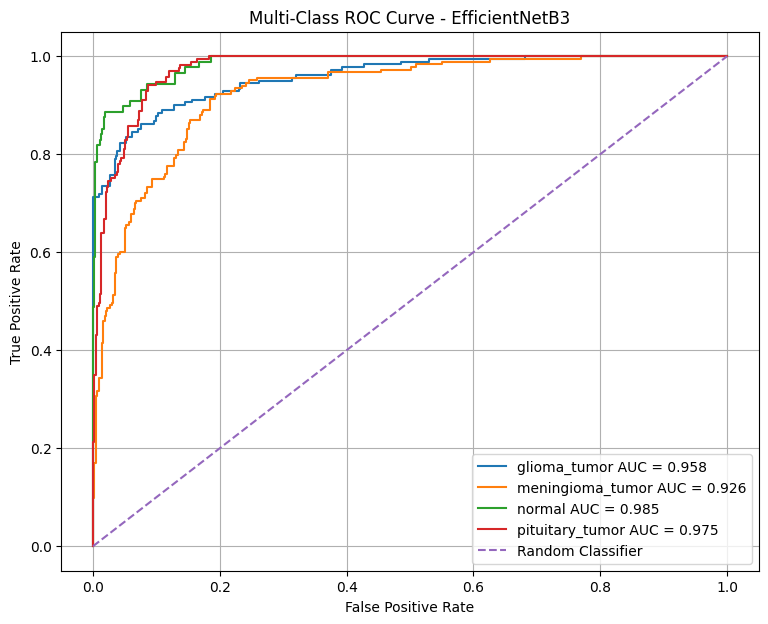

Per-class AUC scores:
glioma_tumor: 0.9583
meningioma_tumor: 0.9264
normal: 0.9854
pituitary_tumor: 0.9753

Macro AUC-ROC: 0.9613
Weighted AUC-ROC: 0.9574


In [ ]:
# =========================
# 44. MULTI-CLASS AUC-ROC FOR EFFICIENTNETB3
# =========================

tl_test_generator.reset()

y_prob = efficientnet_model.predict(tl_test_generator)
y_true_auc = tl_test_generator.classes

num_classes = len(class_names)

y_true_bin = label_binarize(
    y_true_auc,
    classes=list(range(num_classes))
)

plt.figure(figsize=(9, 7))

auc_scores = {}

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    auc_scores[class_names[i]] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.3f}"
    )

macro_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("Multi-Class ROC Curve - EfficientNetB3")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("Per-class AUC scores:")
for class_name, score in auc_scores.items():
    print(f"{class_name}: {score:.4f}")

print(f"\nMacro AUC-ROC: {macro_auc:.4f}")
print(f"Weighted AUC-ROC: {weighted_auc:.4f}")

Last convolutional layer used for Grad-CAM: top_conv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


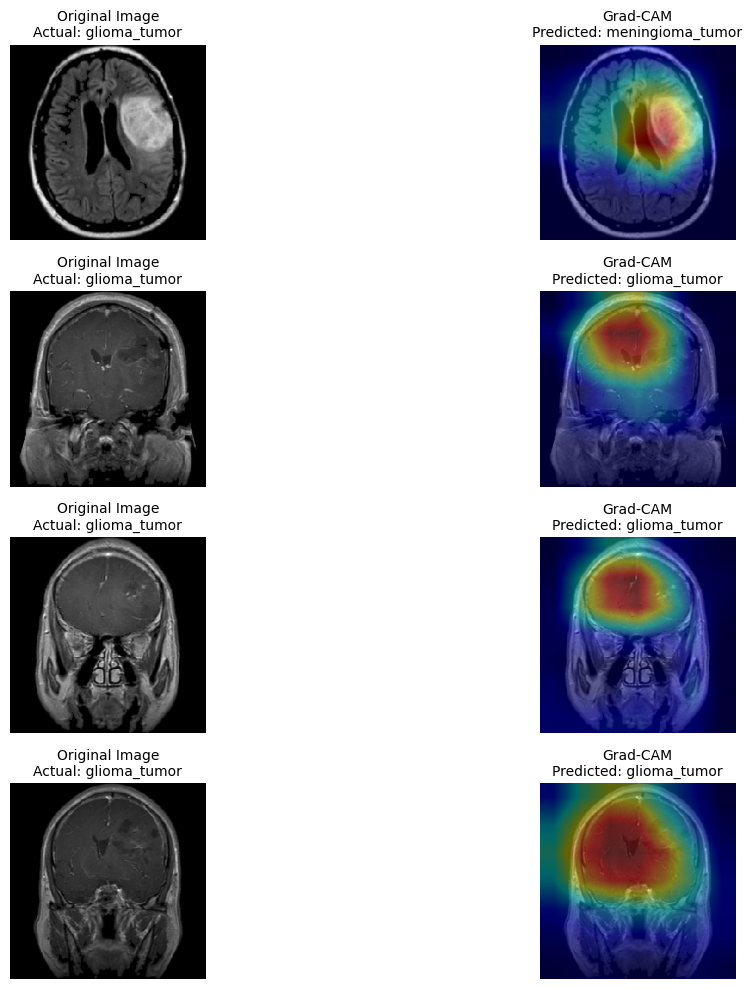

In [ ]:
# =========================
# 45. FIXED GRAD-CAM VISUALIZATION FOR EFFICIENTNETB3
# =========================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model

# ------------------------------------------------------------
# Helper: find last Conv2D layer automatically
# ------------------------------------------------------------
def find_last_conv_layer_name(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in EfficientNet base model.")


# ------------------------------------------------------------
# Helper: display image safely
# Works even if image is preprocessed
# ------------------------------------------------------------
def display_image_safely(img):
    img = np.array(img).astype("float32")

    # If image has negative values or large values, normalize for display
    img_min = img.min()
    img_max = img.max()

    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)

    img = np.clip(img, 0, 1)
    return img


# ------------------------------------------------------------
# Grad-CAM heatmap function
# This version works with nested EfficientNetB3 model
# ------------------------------------------------------------
def make_gradcam_heatmap(img_array, full_model, base_model, last_conv_layer_name, pred_index=None):
    """
    Creates Grad-CAM heatmap for EfficientNetB3 nested inside full model.
    """

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Model that returns both last conv output and base model final output
    feature_model = Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Find layers after EfficientNetB3 in the full model
    classifier_layers = []
    found_base = False

    for layer in full_model.layers:
        if layer.name == base_model.name:
            found_base = True
            continue

        if found_base:
            classifier_layers.append(layer)

    with tf.GradientTape() as tape:
        conv_outputs, base_output = feature_model(img_array, training=False)

        x = base_output

        # Pass base output through classifier head manually
        for layer in classifier_layers:
            x = layer(x, training=False)

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients spatially
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight convolution outputs with gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and normalize
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy()


# ------------------------------------------------------------
# Create Grad-CAM overlay
# ------------------------------------------------------------
def create_gradcam_overlay(img, heatmap, alpha=0.4):
    """
    Creates heatmap overlay on original MRI image.
    """

    display_img = display_image_safely(img)
    display_img_uint8 = np.uint8(255 * display_img)

    heatmap = cv2.resize(
        heatmap,
        (display_img_uint8.shape[1], display_img_uint8.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        display_img_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay


# ------------------------------------------------------------
# Show Grad-CAM examples
# ------------------------------------------------------------
def show_gradcam_examples(full_model, base_model, generator, class_names, num_images=4):
    generator.reset()

    images, labels = next(generator)

    last_conv_layer_name = find_last_conv_layer_name(base_model)

    print("Last convolutional layer used for Grad-CAM:", last_conv_layer_name)

    predictions = full_model.predict(images)

    plt.figure(figsize=(14, 10))

    total_images = min(num_images, len(images))

    for i in range(total_images):
        img = images[i]
        img_array = np.expand_dims(img, axis=0)

        pred_class_index = np.argmax(predictions[i])
        true_class_index = np.argmax(labels[i])

        heatmap = make_gradcam_heatmap(
            img_array=img_array,
            full_model=full_model,
            base_model=base_model,
            last_conv_layer_name=last_conv_layer_name,
            pred_index=pred_class_index
        )

        overlay = create_gradcam_overlay(
            img=img,
            heatmap=heatmap,
            alpha=0.4
        )

        original_img = display_image_safely(img)

        plt.subplot(total_images, 2, (i * 2) + 1)
        plt.imshow(original_img)
        plt.axis("off")
        plt.title(
            f"Original Image\nActual: {class_names[true_class_index]}",
            fontsize=10
        )

        plt.subplot(total_images, 2, (i * 2) + 2)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(
            f"Grad-CAM\nPredicted: {class_names[pred_class_index]}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Run Grad-CAM
# ------------------------------------------------------------
show_gradcam_examples(
    full_model=efficientnet_model,
    base_model=efficientnet_base,
    generator=tl_test_generator,
    class_names=class_names,
    num_images=4
)

### Grad-CAM Interpretation

Grad-CAM was applied to the final EfficientNetB3 transfer learning model to visualize which regions of the MRI images influenced the prediction. The heatmap overlay highlights the most important spatial regions used by the model during classification.

This is important in medical image classification because the model should focus on meaningful brain or tumor regions rather than irrelevant background areas. The Grad-CAM results improve interpretability and support the project proposal objective of validating whether the model attends to clinically relevant MRI regions.

In [ ]:
# =========================
# 46. FINAL MODEL COMPARISON TABLE
# =========================

results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN Adam",
        "Deep CNN SGD",
        "Ablation No Dropout",
        "EfficientNetB3 Transfer Learning"
    ],
    "Test Loss": [
        baseline_loss,
        deep_loss,
        sgd_loss,
        ablation_loss,
        eff_loss
    ],
    "Test Accuracy": [
        baseline_acc,
        deep_acc,
        sgd_acc,
        ablation_acc,
        eff_acc
    ],
    "Training Time Seconds": [
        baseline_time,
        deep_time,
        deep_sgd_time,
        ablation_time,
        eff_phase1_time + eff_phase2_time
    ]
})

display(results_df)

,Model,Test Loss,Test Accuracy,Training Time Seconds
0,Baseline CNN,0.806213,0.684380,742.523118
1,Deep CNN Adam,1.708853,0.276973,262.616588
2,Deep CNN SGD,13.188030,0.141707,248.297962
3,Ablation No Dropout,1.758711,0.141707,217.739204
4,EfficientNetB3 Transfer Learning,0.538490,0.824477,822.837321


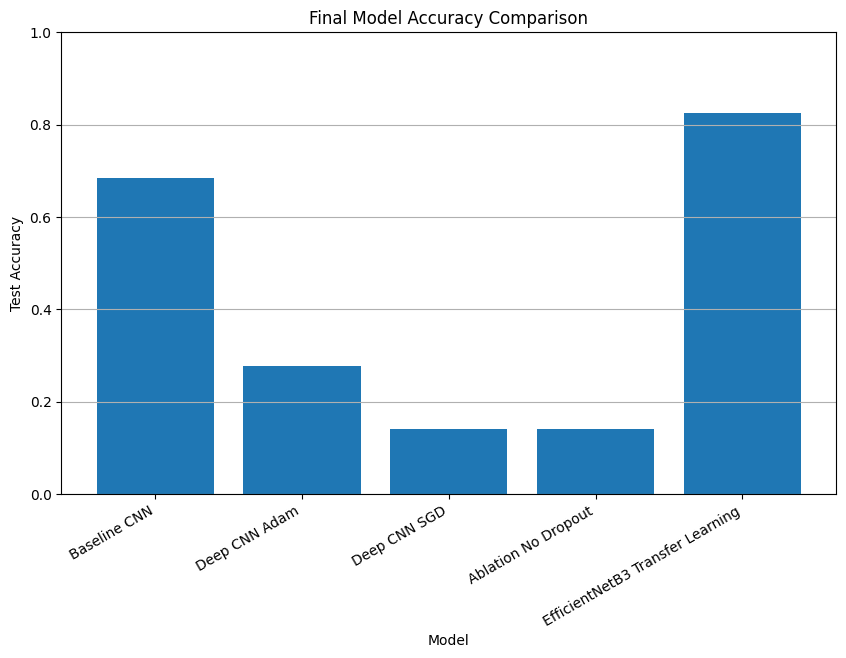

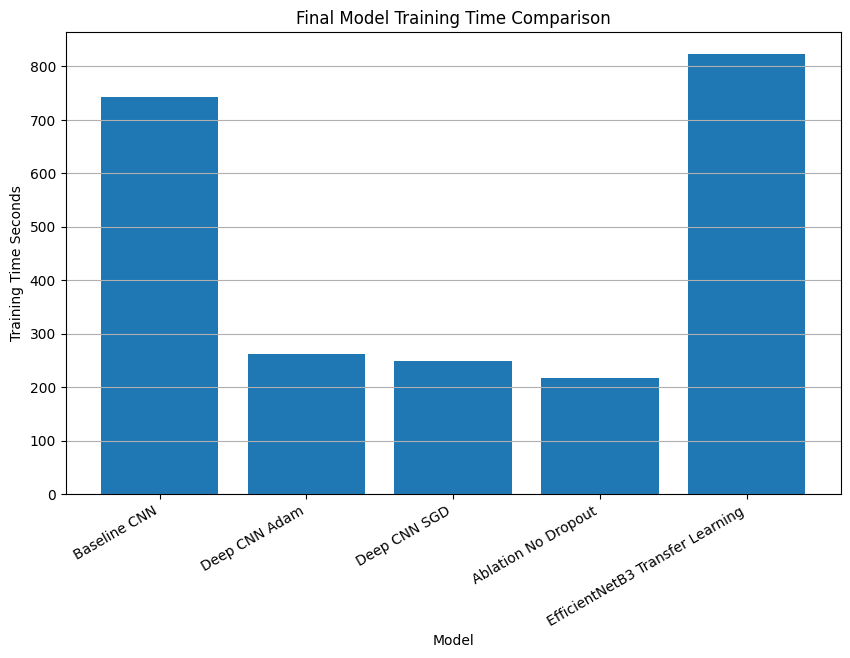

In [ ]:
# =========================
# 47. FINAL MODEL COMPARISON GRAPHS
# =========================

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Training Time Seconds"])
plt.title("Final Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time Seconds")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

### Final Model Comparison Discussion

The baseline CNN was used as the first model trained from scratch using three convolutional layers, three pooling layers, three fully connected layers, and a softmax output layer. This satisfies the baseline CNN architecture requirement.

The deeper CNN expanded the architecture to six convolutional layers with Batch Normalization and Dropout. Since the baseline model used three convolutional layers, the deeper model used double the convolutional depth. This satisfies the requirement for a deeper architecture with regularization.

The optimizer comparison was performed by training the deeper CNN using Adam and SGD. Adam usually converges faster because it adapts the learning rate for each parameter, while SGD with momentum can generalize well but may require more careful tuning.

The ablation study removed Dropout from the deeper CNN to observe the impact of regularization. If the no-dropout model performs worse or shows a larger gap between training and validation accuracy, this indicates overfitting and confirms the importance of Dropout.

EfficientNetB3 transfer learning was used as the final model because the dataset is relatively small and imbalanced. Since EfficientNetB3 already learned useful visual features from ImageNet, it is more suitable than training a CNN completely from scratch. The final comparison table shows the trade-off between accuracy, loss, and training time across all models.

### Discussion on Expected Accuracy

The project proposal expected the EfficientNetB3 transfer learning model to achieve accuracy above 90%. However, the final test accuracy may be lower than the expected target. This does not mean the experiment failed, because medical image classification is affected by several practical challenges.

Possible reasons for the lower-than-expected accuracy include limited dataset size, class imbalance, visual similarity between glioma and meningioma tumors, removal of corrupted images, and variation in MRI image quality, contrast, and orientation. The normal class also contains fewer samples than the tumor classes, which may affect model generalization.

Despite not reaching the proposed 90% target, the transfer learning model can still demonstrate stronger performance than custom CNN models trained from scratch. This supports the conclusion that pretrained CNN architectures such as EfficientNetB3 are more suitable for small-scale medical imaging datasets than CNN models trained entirely from scratch.

In [ ]:
# =========================
# 48. SAVE MODELS AND RESULTS
# =========================

SAVE_DIR = "/content/brain_tumor_task2_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(os.path.join(SAVE_DIR, "baseline_cnn_brain_tumor.h5"))
deep_model.save(os.path.join(SAVE_DIR, "deep_cnn_brain_tumor_adam.h5"))
deep_sgd_model.save(os.path.join(SAVE_DIR, "deep_cnn_brain_tumor_sgd.h5"))
ablation_model.save(os.path.join(SAVE_DIR, "ablation_no_dropout_brain_tumor.h5"))
efficientnet_model.save(os.path.join(SAVE_DIR, "efficientnet_b3_brain_tumor.h5"))

results_df.to_csv(
    os.path.join(SAVE_DIR, "final_model_comparison_results.csv"),
    index=False
)

print("All models and final comparison results saved successfully.")
print("Saved folder:", SAVE_DIR)

All models and final comparison results saved successfully.
Saved folder: /content/brain_tumor_task2_outputs


In [ ]:
# =========================
# 49. ZIP OUTPUT FILES
# =========================

shutil.make_archive(
    "/content/brain_tumor_task2_outputs",
    "zip",
    SAVE_DIR
)

print("ZIP file created at: /content/brain_tumor_task2_outputs.zip")

ZIP file created at: /content/brain_tumor_task2_outputs.zip
